# SQL Agent with LangGraph — Walmart Sales (Part 2)
**Goal:** Reinforce the LangGraph SQL agent pattern with additional Walmart Sales queries

## Libraries

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

# LangGraph
from langgraph.graph import END, StateGraph
from typing import TypedDict

import pandas as pd
import sqlalchemy as sql
import os
import re
import yaml
from pprint import pprint

C:\Users\User\AppData\Local\Temp\ipykernel_13392\1179844273.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini")

## 1.0 SQL Database Setup

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

db = SQLDatabase.from_uri(PATH_DB)

print("Tables:", db.get_usable_table_names())

Tables: ['daily_demand']


## 2.0 SQL Parsing Utility

In [4]:
def extract_sql_code(text: str):
    """Extract the SQL query from an LLM response. Returns None if not found."""
    if not text:
        return None
    for pat in [
        r"SQLQuery:\s*```sql\s*([\s\S]+?)```",
        r"```sql\s*([\s\S]+?)```",
        r"```[\w]*\s*(SELECT[\s\S]+?)```",
        r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)",
        r"(SELECT[\s\S]+?)(?:;|\n\n|$)",
    ]:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return m.group(1).strip().rstrip(";")
    return None

## 3.0 SQL Agent

In [5]:
sql_generator = create_sql_query_chain(
    llm=llm,
    db=db,
    k=int(1e7),  # Set high to avoid LIMIT truncation
)

sql_generator

RunnableAssign(mapper={
  input: RunnableLambda(...),
  table_info: RunnableLambda(...)
})
| RunnableLambda(lambda x: {k: v for k, v in x.items() if k not in ('question', 'table_names_to_use')})
| PromptTemplate(input_variables=['input', 'table_info'], input_types={}, partial_variables={'top_k': '10000000'}, template='You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.\nUnless the user specifies in the question a specific number of examples to obtain, query for at most {top_k} results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.\nNever query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.\nPay attention to use only the column names you can see

In [6]:
# Test the SQL generator directly
response = sql_generator.invoke({"question": "Which item had the single highest daily demand value, and on what date?"})
sql_q = extract_sql_code(response)
pprint(sql_q)
pd.read_sql(sql_q, conn)

('SELECT "item_id", "value", "date" FROM daily_demand ORDER BY "value" DESC '
 'LIMIT 1')


,item_id,value,date
0,FOODS_3_090,2532,2013-09-01


In [7]:
response = sql_generator.invoke({"question": "How many unique items are in the daily_demand table?"})
sql_q = extract_sql_code(response)
pprint(sql_q)
pd.read_sql(sql_q, conn)

'SELECT COUNT(DISTINCT "item_id") AS unique_items FROM daily_demand'


,unique_items
0,12


## 4.0 LangGraph Workflow

In [8]:
class GraphState(TypedDict):
    """Represents the state of our graph."""
    question: str
    sql_query: str

In [9]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("question")
    sql_query = sql_generator.invoke({"question": question})
    sql_query = extract_sql_code(sql_query)
    return {"sql_query": sql_query}

In [10]:
def state_printer(state):
    """Print the state."""
    print("---STATE PRINTER---")
    print(f"question: {state.get('question')}")
    pprint(f"SQL Query:\n{state.get('sql_query')}")

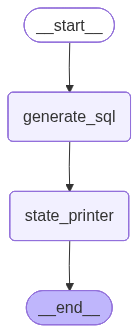

In [11]:
workflow = StateGraph(GraphState)

workflow.add_node("generate_sql", generate_sql)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()
app

## 5.0 Testing the Graph

In [12]:
QUESTION = "What is the total demand value by year?"

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What is the total demand value by year?
('SQL Query:\n'
 'SELECT strftime(\'%Y\', "date") AS "year", SUM("value") AS "total_demand" \n'
 'FROM daily_demand \n'
 'GROUP BY "year" \n'
 'ORDER BY "year"')
('SELECT strftime(\'%Y\', "date") AS "year", SUM("value") AS "total_demand" \n'
 'FROM daily_demand \n'
 'GROUP BY "year" \n'
 'ORDER BY "year"')


,year,total_demand
0,2011,924780
1,2012,1237760
2,2013,1128577
3,2014,1012332
4,2015,1035293
5,2016,331249


In [13]:
QUESTION = "What are the top 5 items by total demand value in 2015?"

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What are the top 5 items by total demand value in 2015?
('SQL Query:\n'
 'SELECT "item_id", SUM("value") as "total_demand"\n'
 'FROM "daily_demand"\n'
 'WHERE strftime(\'%Y\', "date") = \'2015\'\n'
 'GROUP BY "item_id"\n'
 'ORDER BY "total_demand" DESC\n'
 'LIMIT 5')
('SELECT "item_id", SUM("value") as "total_demand"\n'
 'FROM "daily_demand"\n'
 'WHERE strftime(\'%Y\', "date") = \'2015\'\n'
 'GROUP BY "item_id"\n'
 'ORDER BY "total_demand" DESC\n'
 'LIMIT 5')


,item_id,total_demand
0,FOODS_3_586,162918
1,FOODS_3_090,157275
2,FOODS_3_252,110849
3,FOODS_3_120,94404
4,FOODS_3_587,91954


In [14]:
QUESTION = "What is the average daily demand value for item FOODS_3_090 by year?"

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What is the average daily demand value for item FOODS_3_090 by year?
('SQL Query:\n'
 'SELECT strftime(\'%Y\', "date") AS "year", AVG("value") AS "average_demand"\n'
 'FROM daily_demand\n'
 'WHERE "item_id" = \'FOODS_3_090\'\n'
 'GROUP BY "year"\n'
 'ORDER BY "year"')
('SELECT strftime(\'%Y\', "date") AS "year", AVG("value") AS "average_demand"\n'
 'FROM daily_demand\n'
 'WHERE "item_id" = \'FOODS_3_090\'\n'
 'GROUP BY "year"\n'
 'ORDER BY "year"')


,year,average_demand
0,2011,316.510386
1,2012,722.601093
2,2013,710.350685
3,2014,424.797260
4,2015,430.890411
5,2016,519.904348


In [15]:
conn.close()